# VAE V1 and V2 for CASIA Digital Evidence Analysis

**Faculty demonstration — baseline VAE and KL-warm-up VAE V2**

V1 is preserved as the baseline. V2 uses linear KL beta warm-up to improve reconstruction while retaining a probabilistic latent representation. These experiments do not constitute forgery classification.

## Section 1 — Project and VAE objective

This VAE module belongs to *Multi-Model Generative AI Framework for Digital Evidence Analysis and Intelligence Generation*. It reconstructs 128×128 RGB images, learns a continuous latent distribution, and generates synthetic research images.

In [1]:
# Run once at the top. In Colab this clones code only when needed.
from pathlib import Path
import os, sys, subprocess
IN_COLAB = 'google.colab' in sys.modules
repo_name = 'Digital-Evidence-GenAI'
if IN_COLAB:
    base = Path('/content')
    PROJECT_ROOT = base / repo_name
    if not PROJECT_ROOT.exists():
        subprocess.run(['git','clone','https://github.com/chetanraje27/Digital-Evidence-GenAI.git',str(PROJECT_ROOT)], check=True)
    subprocess.run([sys.executable,'-m','pip','install','-q','kagglehub','scikit-image','torchmetrics','torch-fidelity'], check=True)
else:
    here = Path.cwd().resolve()
    PROJECT_ROOT = next((p for p in [here, *here.parents] if (p/'src'/'vae.py').exists()), here)
sys.path.insert(0, str(PROJECT_ROOT/'src'))
TRAIN_VAE = False  # Faculty demo default: never retrain
print('Project:', PROJECT_ROOT)
print('TRAIN_VAE:', TRAIN_VAE)

Project: C:\Users\Chetanraje\Desktop\GAA\Digital_Evidence
TRAIN_VAE: False


## Section 2 — CASIA dataset overview

- CASIA v2.0: **12,614** RGB images
- Authentic: **7,491**; tampered: **5,123**
- Ground-truth masks are excluded from VAE input
- Held-out test set: **1,892** images (1,123 authentic, 769 tampered)

## Section 3 — Data preprocessing and splits

Images are safely opened with PIL, converted to RGB, resized to 128×128, converted to tensors, and scaled to `[0,1]` without ImageNet normalization. Reproducible seed-42 stratified splits are 70% train, 15% validation, and 15% test. Labels are metadata only.

In [2]:
# Download CASIA only if the relative manifest images are unavailable (Colab).
import csv
first = next(csv.DictReader(open(PROJECT_ROOT/'data/splits/test.csv', encoding='utf-8')))
expected = PROJECT_ROOT / first['image_path']
if not expected.exists():
    import kagglehub
    downloaded = Path(kagglehub.dataset_download('divg07/casia-20-image-tampering-detection-dataset'))
    casia2 = next(downloaded.rglob('CASIA2'))
    target = PROJECT_ROOT/'data/raw/CASIA2'
    target.parent.mkdir(parents=True, exist_ok=True)
    if not target.exists(): os.symlink(casia2, target, target_is_directory=True)
print('Dataset ready:', (PROJECT_ROOT/'data/raw/CASIA2').exists())

Dataset ready: True


## Section 4 — VAE architecture

**Encoder:** `3×128×128 → 32×64×64 → 64×32×32 → 128×16×16 → 128×8×8`

The flattened features feed separate **μ** and **log-variance** heads. Reparameterization produces latent **z**, and the transposed-convolution decoder reconstructs `3×128×128` with sigmoid output.

- Latent dimension: **128**
- Parameters: **4,009,795**

In [3]:
import torch
from vae import ConvolutionalVAE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ConvolutionalVAE(latent_dim=128).to(device)
print(model)
print('Parameters:', sum(p.numel() for p in model.parameters()))

ConvolutionalVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU(inplace=True)
  )
  (mu_head): Linear(in_features=8192, out_features=128, bias=True)
  (logvar_head): Linear(in_features=8192, out_features=128, bias=True)
  (decoder_projection): Linear(in_features=128, out_features=8192, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), pad

## Section 5 — Mathematical idea

The encoder learns a Gaussian distribution and samples differentiably:

$$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0,I)$$

$$\mathcal{L}_{total}=\mathcal{L}_{reconstruction}+\beta D_{KL}, \qquad \beta=0.001$$

MSE encourages reconstruction fidelity; KL regularization encourages a smooth latent distribution.

## Section 6 — Training configuration

| Setting | Value |
|---|---:|
| Batch size | 32 |
| Learning rate | 0.0005 |
| Epochs | 30 |
| Optimizer | Adam |
| Latent dimension | 128 |
| β | 0.001 |

## Section 7 — Training results

- GPU: Tesla T4
- Best epoch: **30**
- Best validation total loss: **0.04149372**
- Training time: **1554.43 seconds**

The following are genuine curves recovered from the recorded Colab run. Per-epoch training reconstruction/KL components were not retained, so component plots show validation values only.

### Total training and validation loss

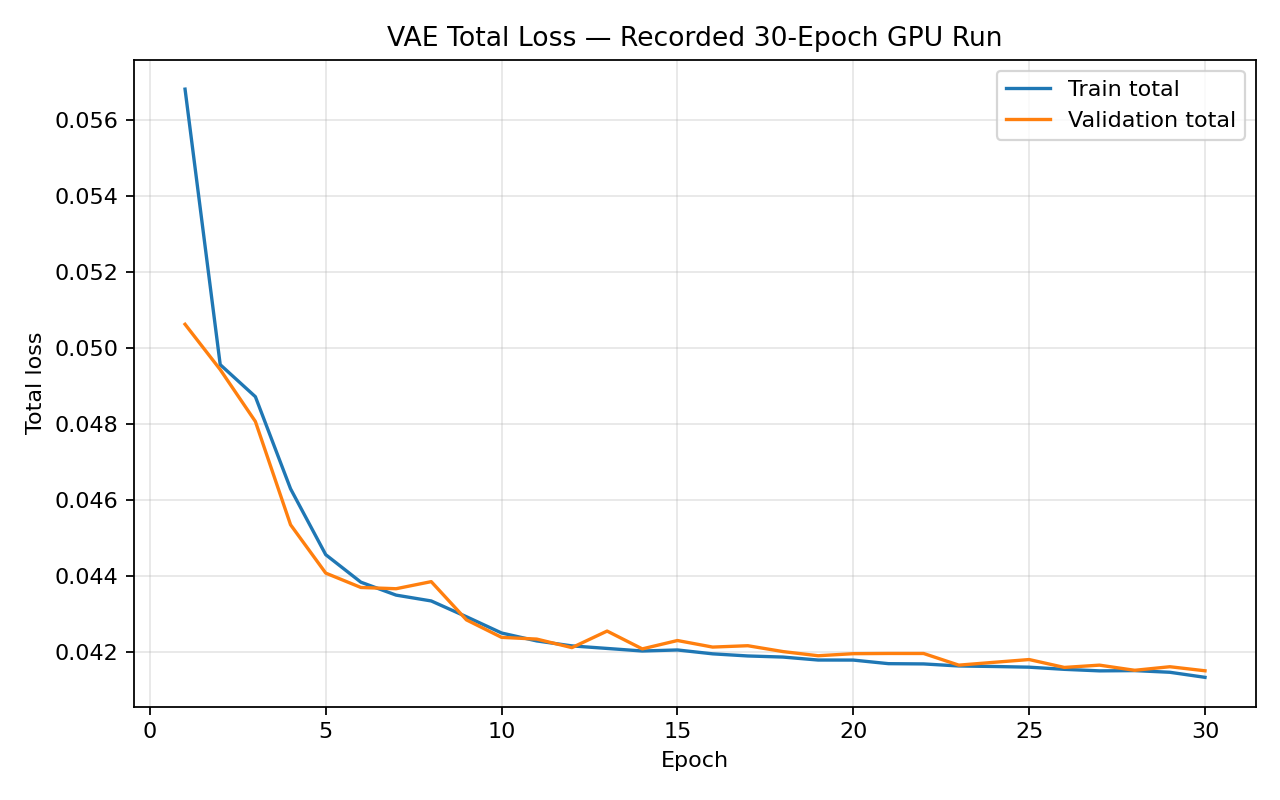

### Validation reconstruction and KL curves

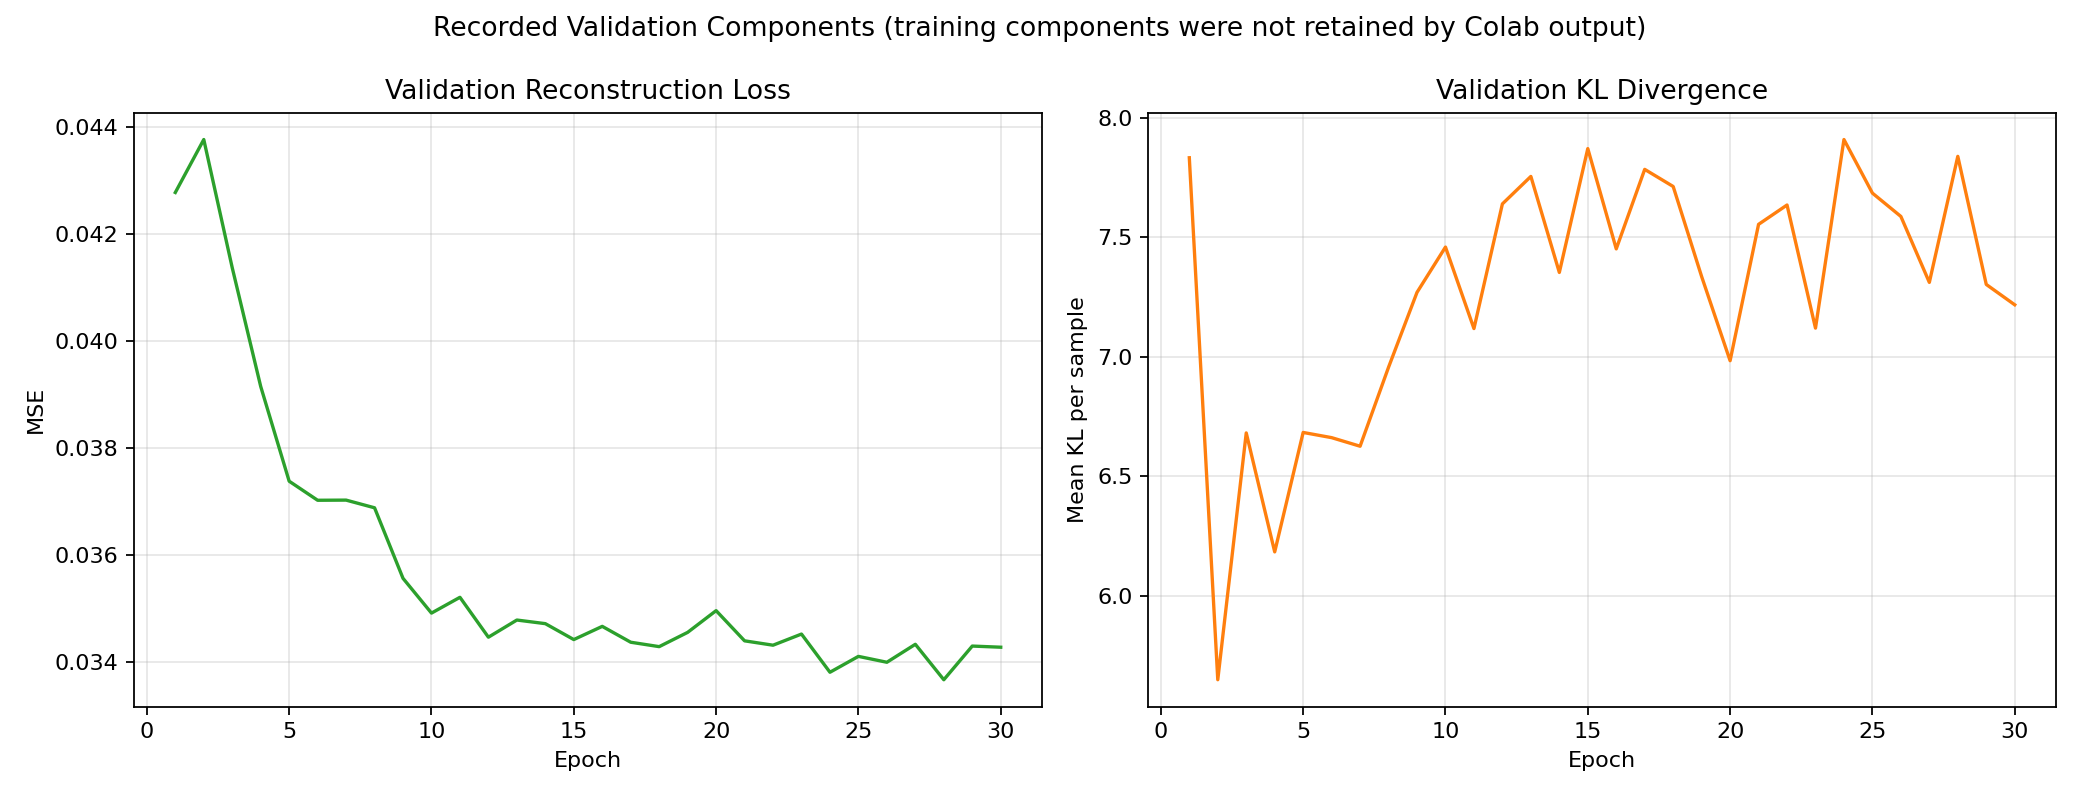

## Section 8 — Reconstruction results

### Original and reconstructed test images

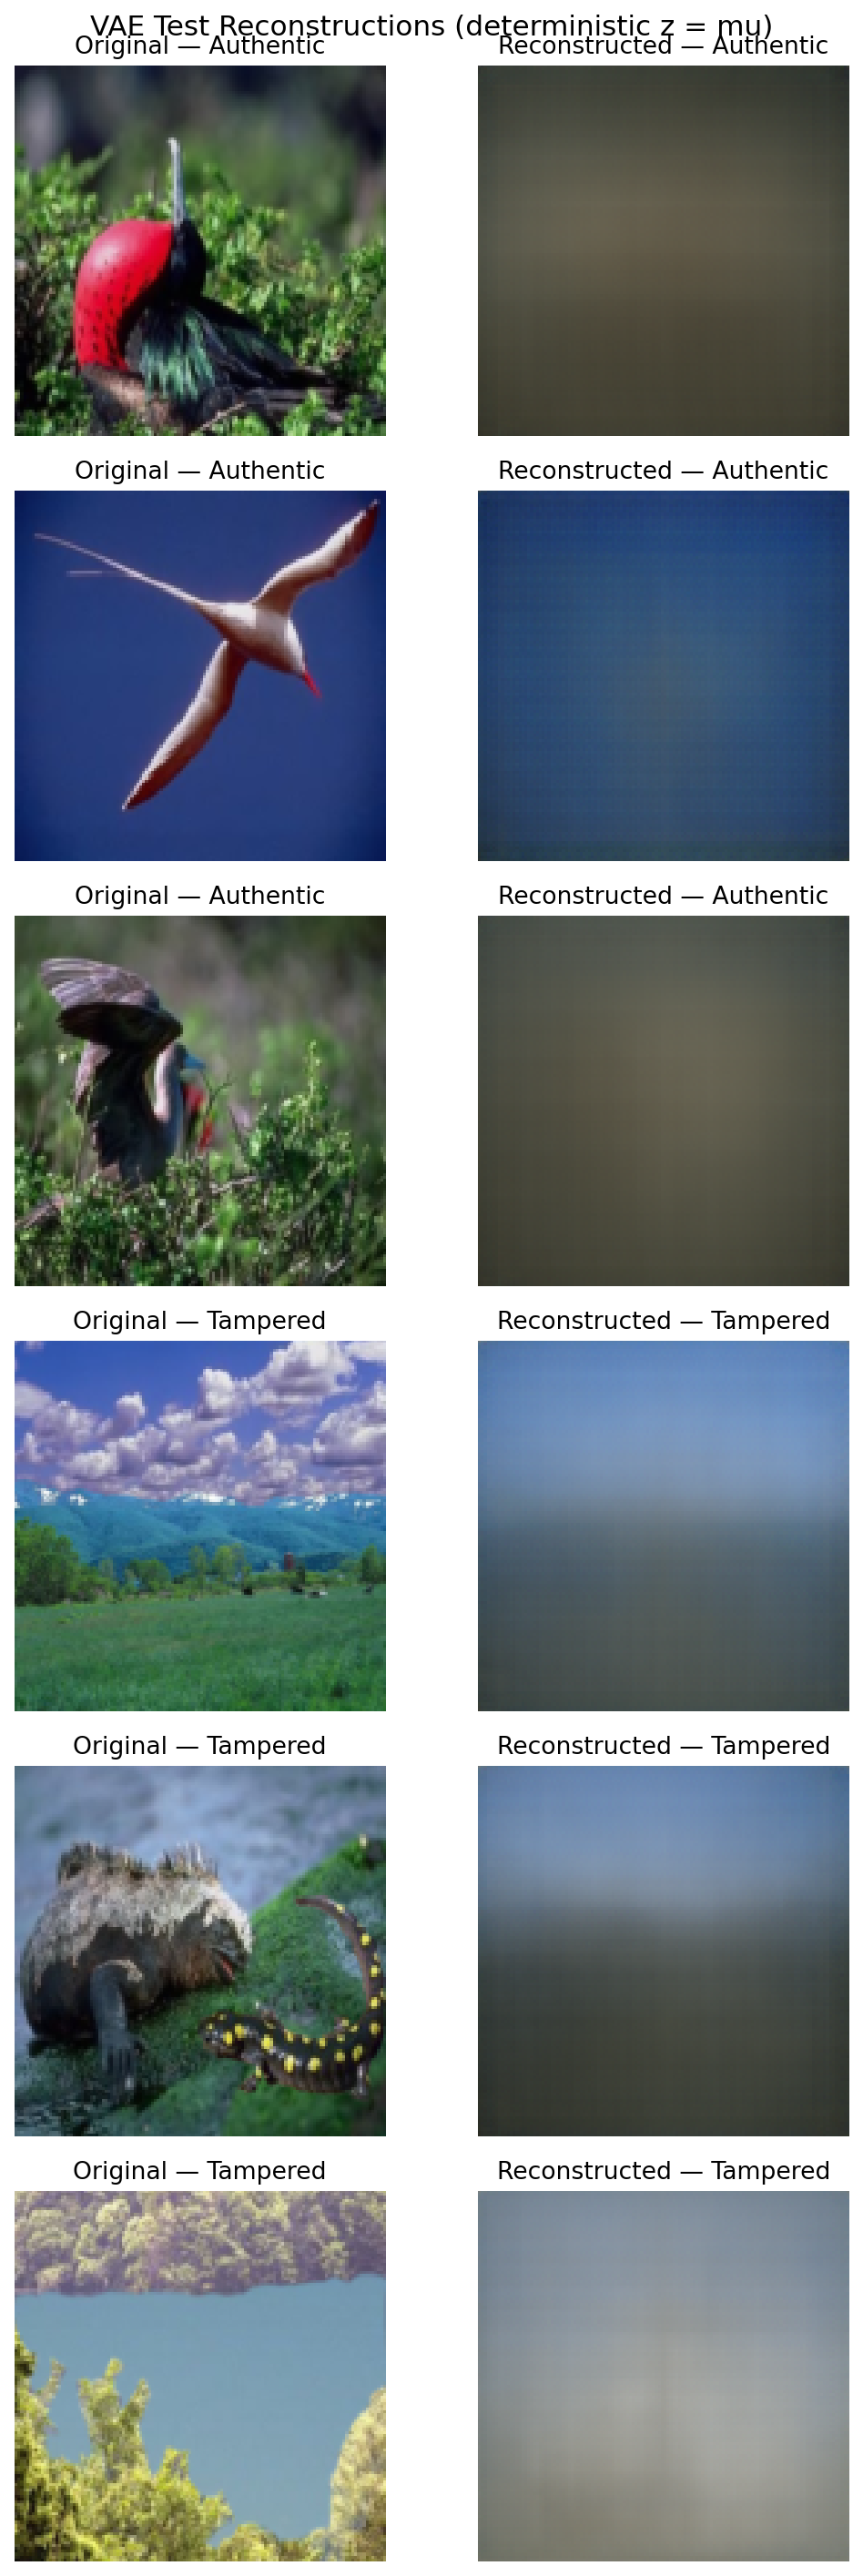

## Section 9 — Test metrics

Metrics are computed per image on the complete held-out test split using deterministic `z = μ`, then averaged. KL is the mean per-sample latent KL; total loss is MSE + 0.001 × KL.

In [4]:
import json
metrics_path = PROJECT_ROOT/'results/vae_test_metrics.json'
metrics = json.loads(metrics_path.read_text())
o = metrics['overall']
print(f"Test images: {metrics['test_images']}")
print(f"MSE: {o['mse_mean']:.8f} | PSNR: {o['psnr_mean']:.4f} dB | SSIM: {o['ssim_mean']:.4f}")
print(f"KL: {o['kl_loss_mean']:.6f} | Total loss: {o['total_loss_mean']:.8f}")

Test images: 1892
MSE: 0.02909885 | PSNR: 15.7895 dB | SSIM: 0.2876
KL: 7.139858 | Total loss: 0.03623871


## Section 10 — Synthetic generation

Samples below are decoded from `z ~ N(0,I)`. They are **synthetic VAE-generated research outputs, not real forensic evidence**.

### Synthetic VAE-generated samples

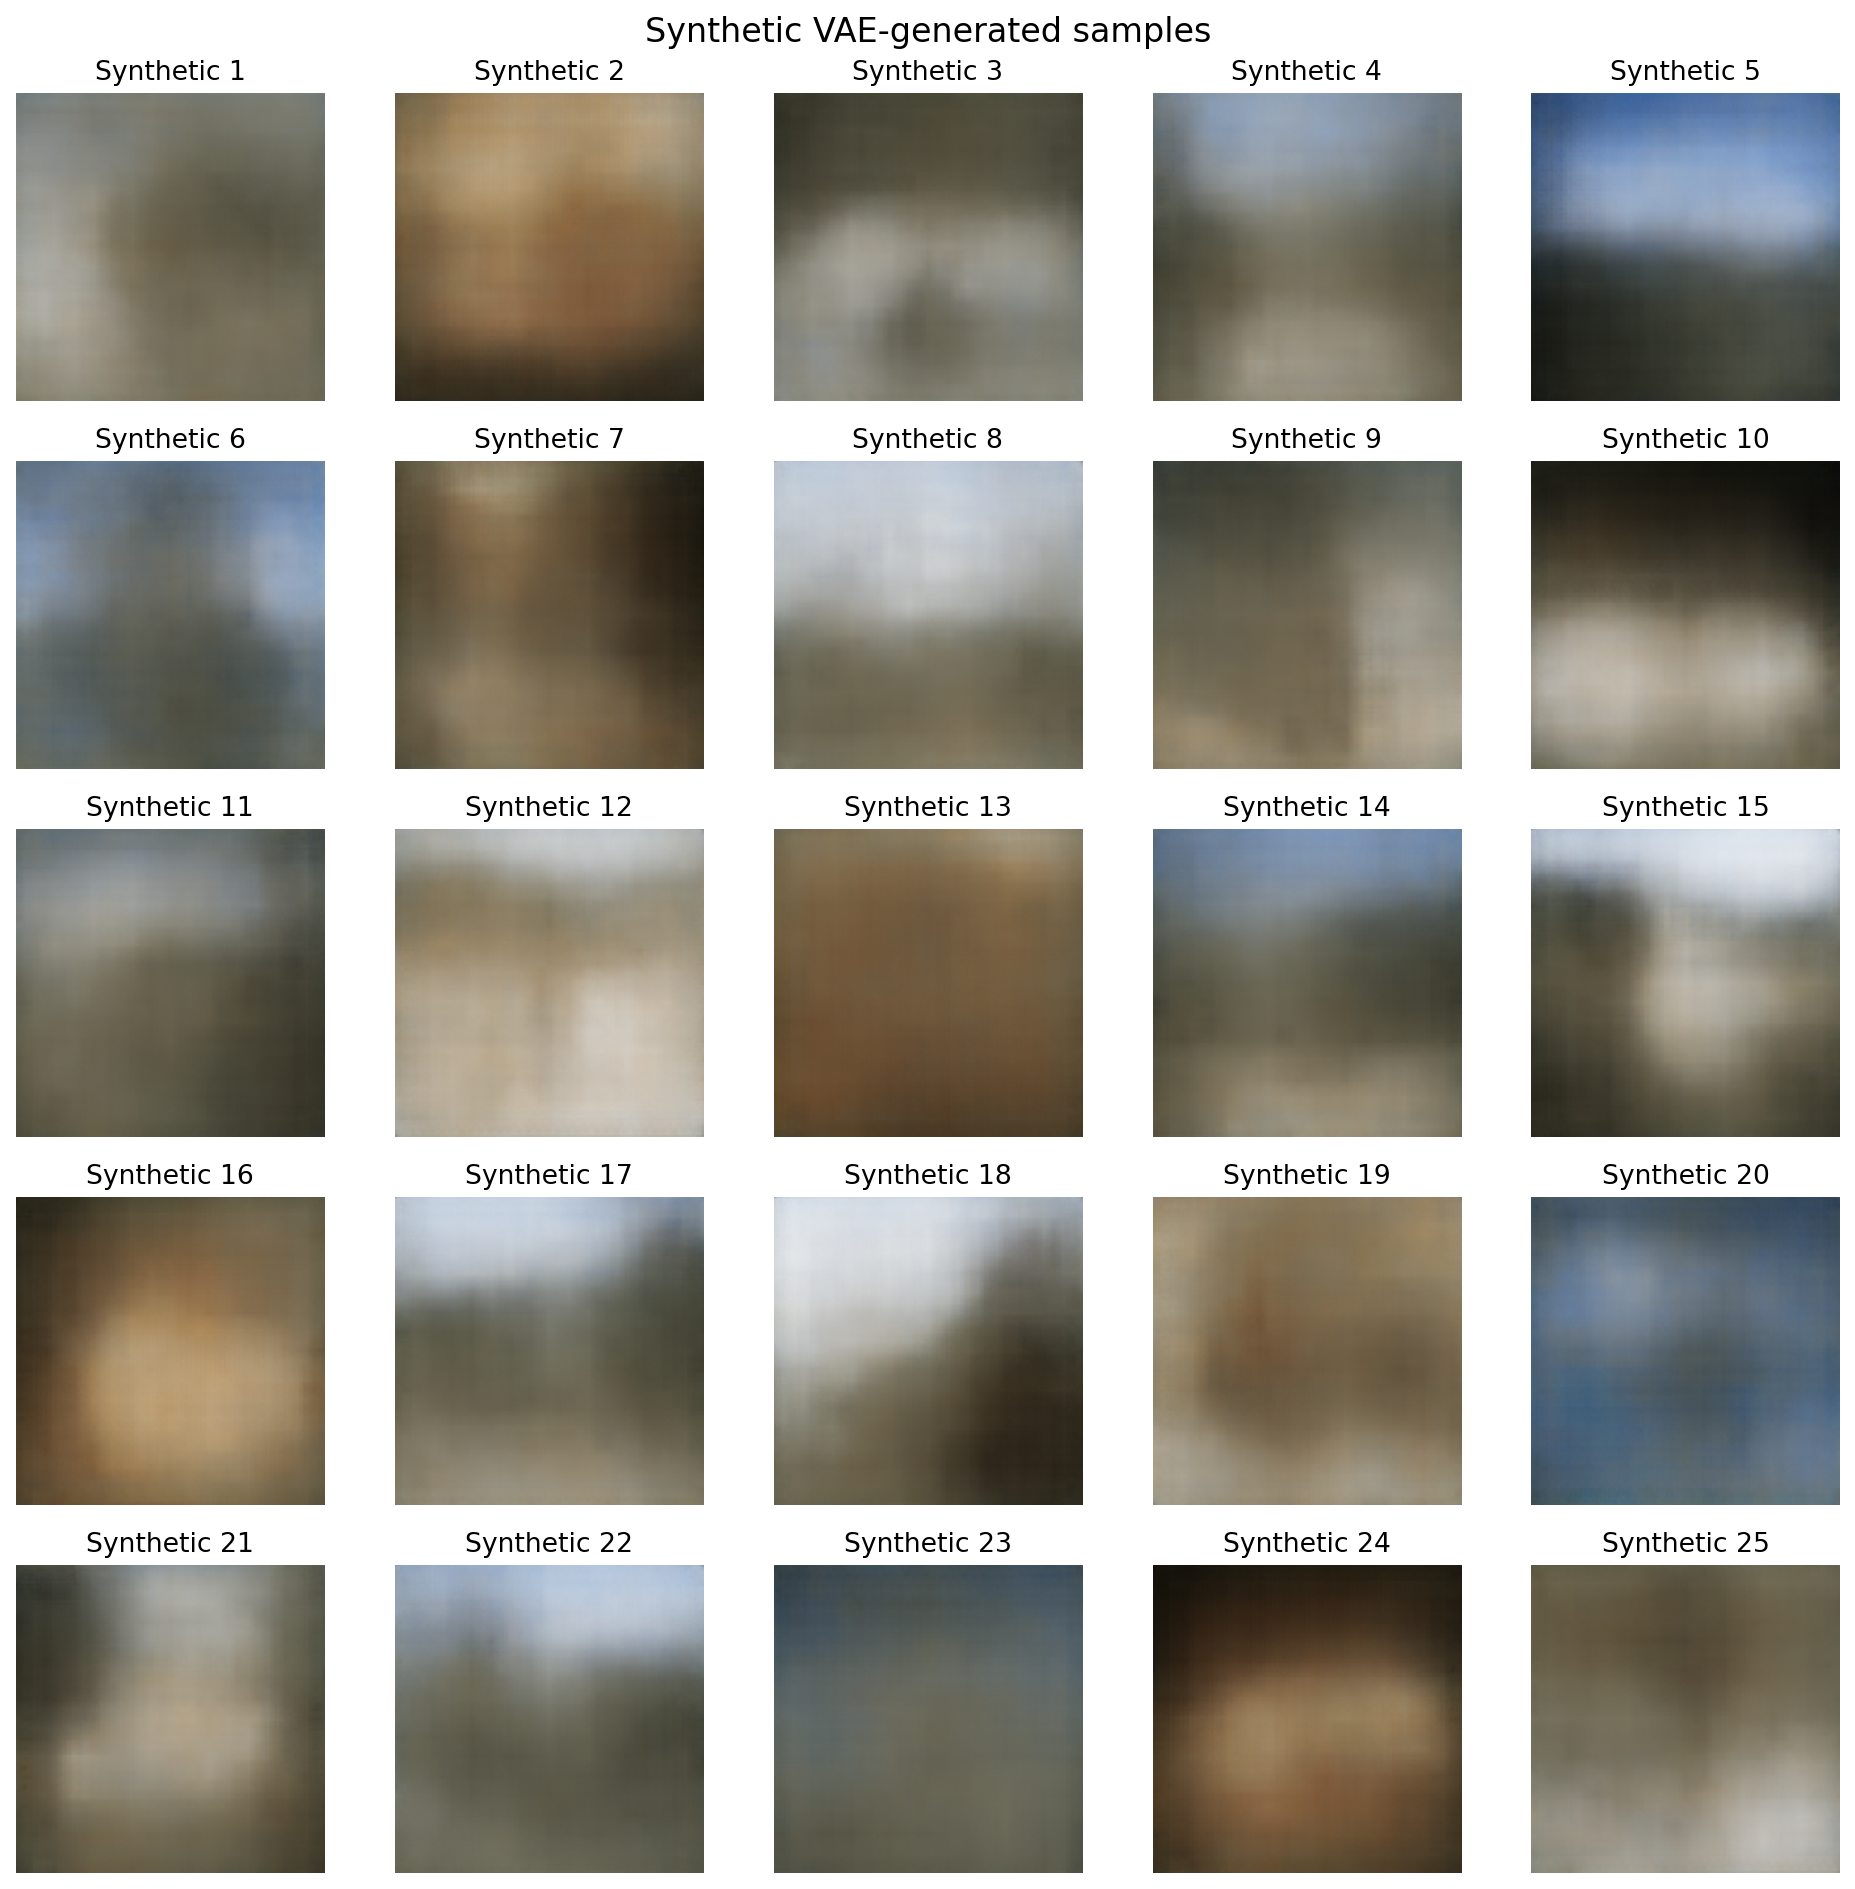

## Section 11 — Latent interpolation

Linear interpolation between two encoded test-image means illustrates a continuous learned latent space.

### Latent interpolation

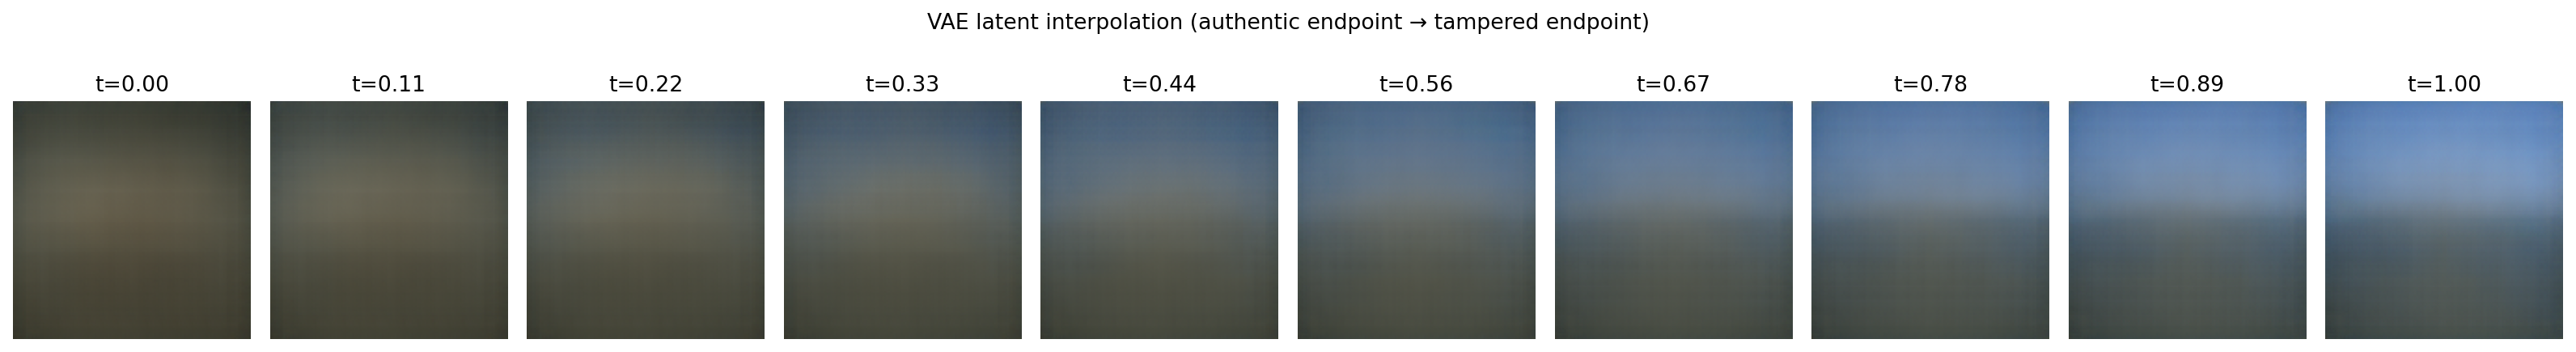

## Section 12 — FID

Lower FID means the generated-image feature distribution is closer to the real-image distribution. This standard Inception-V3 FID uses **1,892 real test images and 1,892 separately generated images**—not only the 25 display samples.

In [5]:
print(f"FID: {metrics['fid']:.4f} ({metrics['fid_implementation']})")

FID: 339.5790 (torchmetrics.image.fid.FrechetInceptionDistance(feature=2048))


## Section 13 — Authentic vs tampered exploratory comparison

These statistics describe reconstruction behavior only. They do **not** make the VAE a forgery detector and do not prove whether an image is forged.

### Authentic vs tampered exploratory metrics

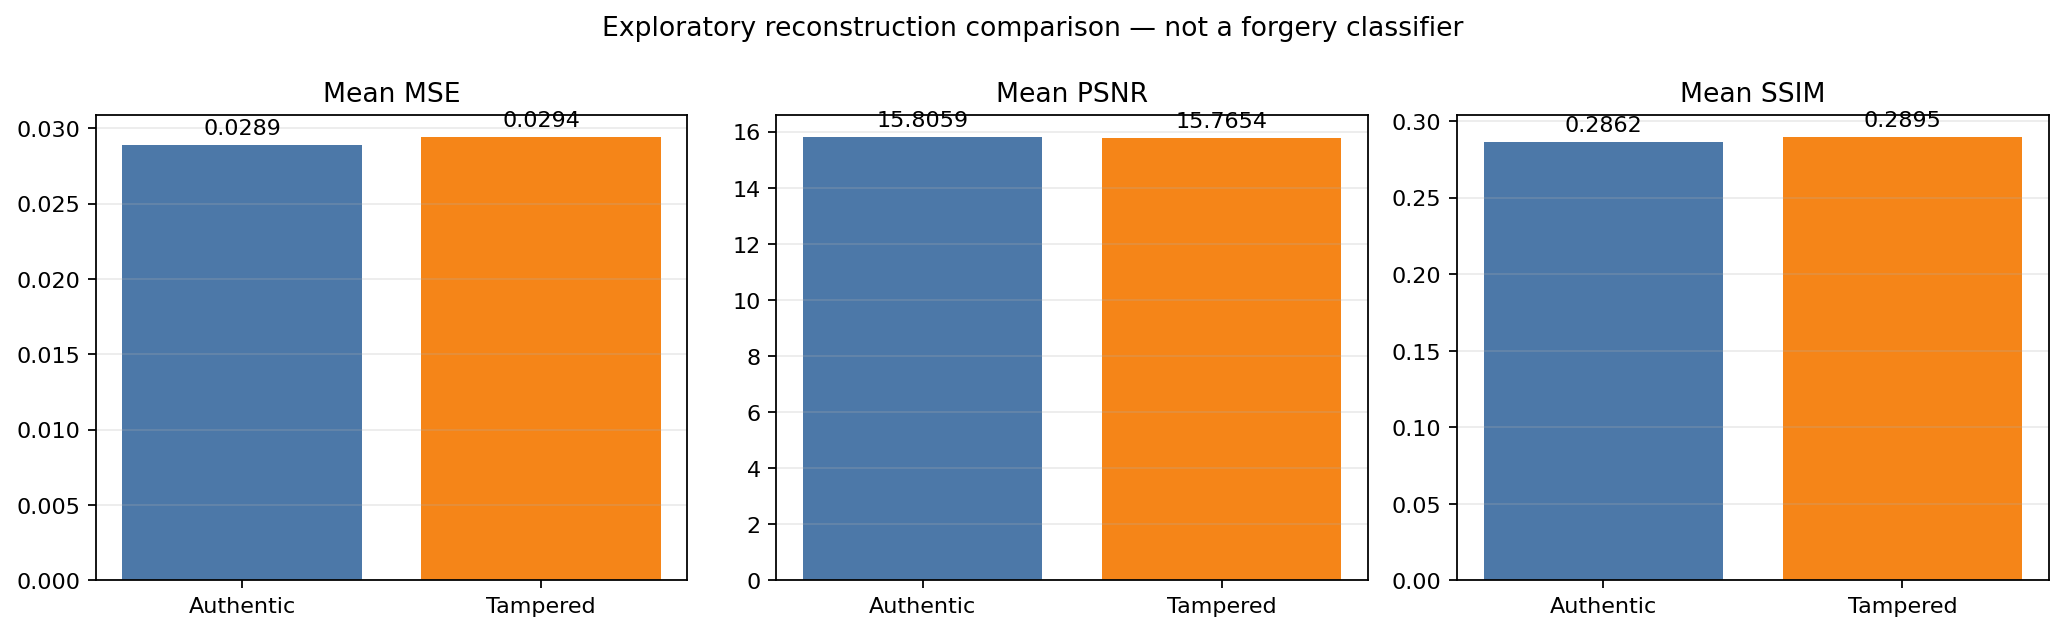

## Section 14 — Conclusion and limitations

- The VAE learned probabilistic latent representations for reconstruction and generation.
- Generated images are synthetic research outputs.
- VAE samples may look smoother or blurrier than GAN outputs.
- Reconstruction statistics are exploratory, not forensic verdicts.
- The team can later compare VAE behavior with AE and GAN results.

## Optional live inference (no training)

In [6]:
# Loads the trained checkpoint; it does not retrain.
checkpoint_path = PROJECT_ROOT/'checkpoints/best_vae.pth'
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict']); model.eval()
print('Loaded:', checkpoint_path, '| epoch:', checkpoint['epoch'])

Loaded: C:\Users\Chetanraje\Desktop\GAA\Digital_Evidence\checkpoints\best_vae.pth | epoch: 30


In [7]:
# Final faculty-demo summary
a, t = metrics['authentic'], metrics['tampered']
print(f"Test images: {metrics['test_images']}")
print(f"Test reconstruction MSE: {o['mse_mean']:.8f}")
print(f"Test PSNR: {o['psnr_mean']:.6f}")
print(f"Test SSIM: {o['ssim_mean']:.6f}")
print(f"Test KL: {o['kl_loss_mean']:.6f}")
print(f"Test total loss: {o['total_loss_mean']:.8f}")
print(f"FID: {metrics['fid']:.6f}")
print(f"Authentic MSE/PSNR/SSIM: {a['mse_mean']:.8f} / {a['psnr_mean']:.6f} / {a['ssim_mean']:.6f}")
print(f"Tampered MSE/PSNR/SSIM: {t['mse_mean']:.8f} / {t['psnr_mean']:.6f} / {t['ssim_mean']:.6f}")
print('Generated samples: 25 display; 1,892 for FID')
print('Latent dimension: 128')
print('Checkpoint:', checkpoint_path)

Test images: 1892
Test reconstruction MSE: 0.02909885
Test PSNR: 15.789473
Test SSIM: 0.287554
Test KL: 7.139858
Test total loss: 0.03623871
FID: 339.578979
Authentic MSE/PSNR/SSIM: 0.02888852 / 15.805923 / 0.286216
Tampered MSE/PSNR/SSIM: 0.02940600 / 15.765450 / 0.289507
Generated samples: 25 display; 1,892 for FID
Latent dimension: 128
Checkpoint: C:\Users\Chetanraje\Desktop\GAA\Digital_Evidence\checkpoints\best_vae.pth


# VAE Version 2 — KL Warm-up Improvement

V2 retains the same CASIA splits, preprocessing, architecture, latent dimension 128, Adam optimizer, learning rate 0.0005, and MSE reconstruction loss. The only training change is linear KL warm-up: beta increases from 0.0001 at epoch 1 to 0.001 at epoch 10 and stays at 0.001 afterward.

## V2 training result

- GPU: **Tesla T4**
- Epochs completed: **48/50**
- Best epoch: **43**
- Early stopping: **Yes**
- Best validation total loss: **0.04100876**
- Training time: **1363.93 seconds**

### VAE V2 loss curves and beta warm-up

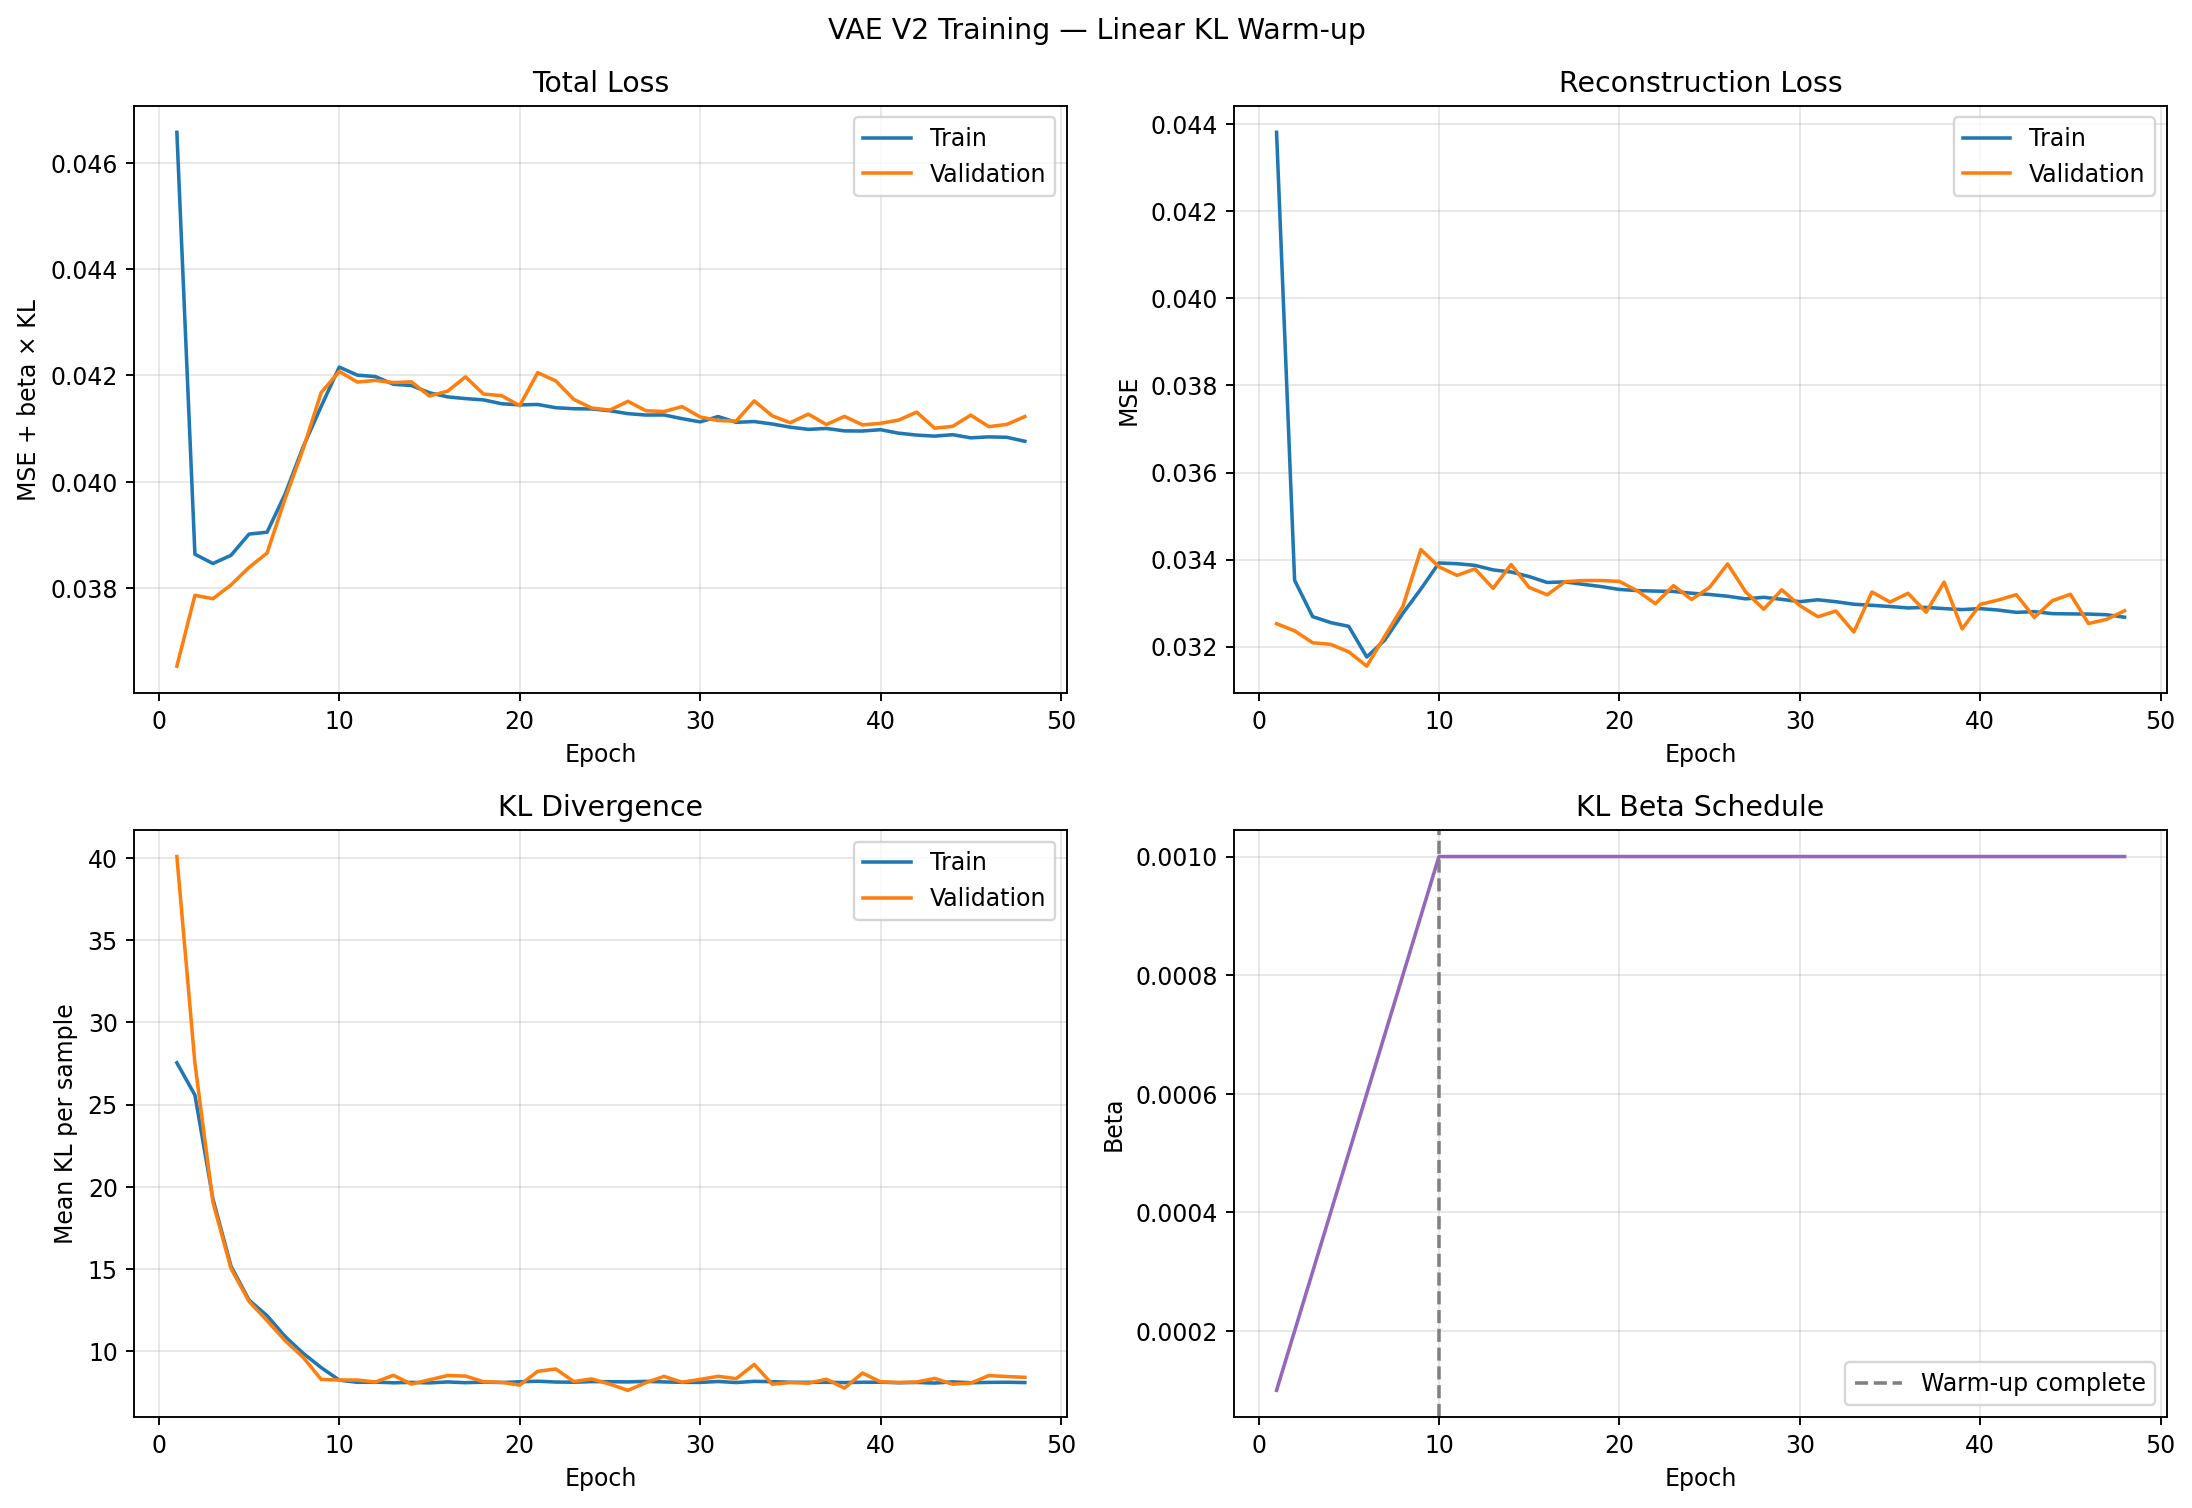

## V1 versus V2 reconstruction

### Original | V1 reconstruction | V2 reconstruction

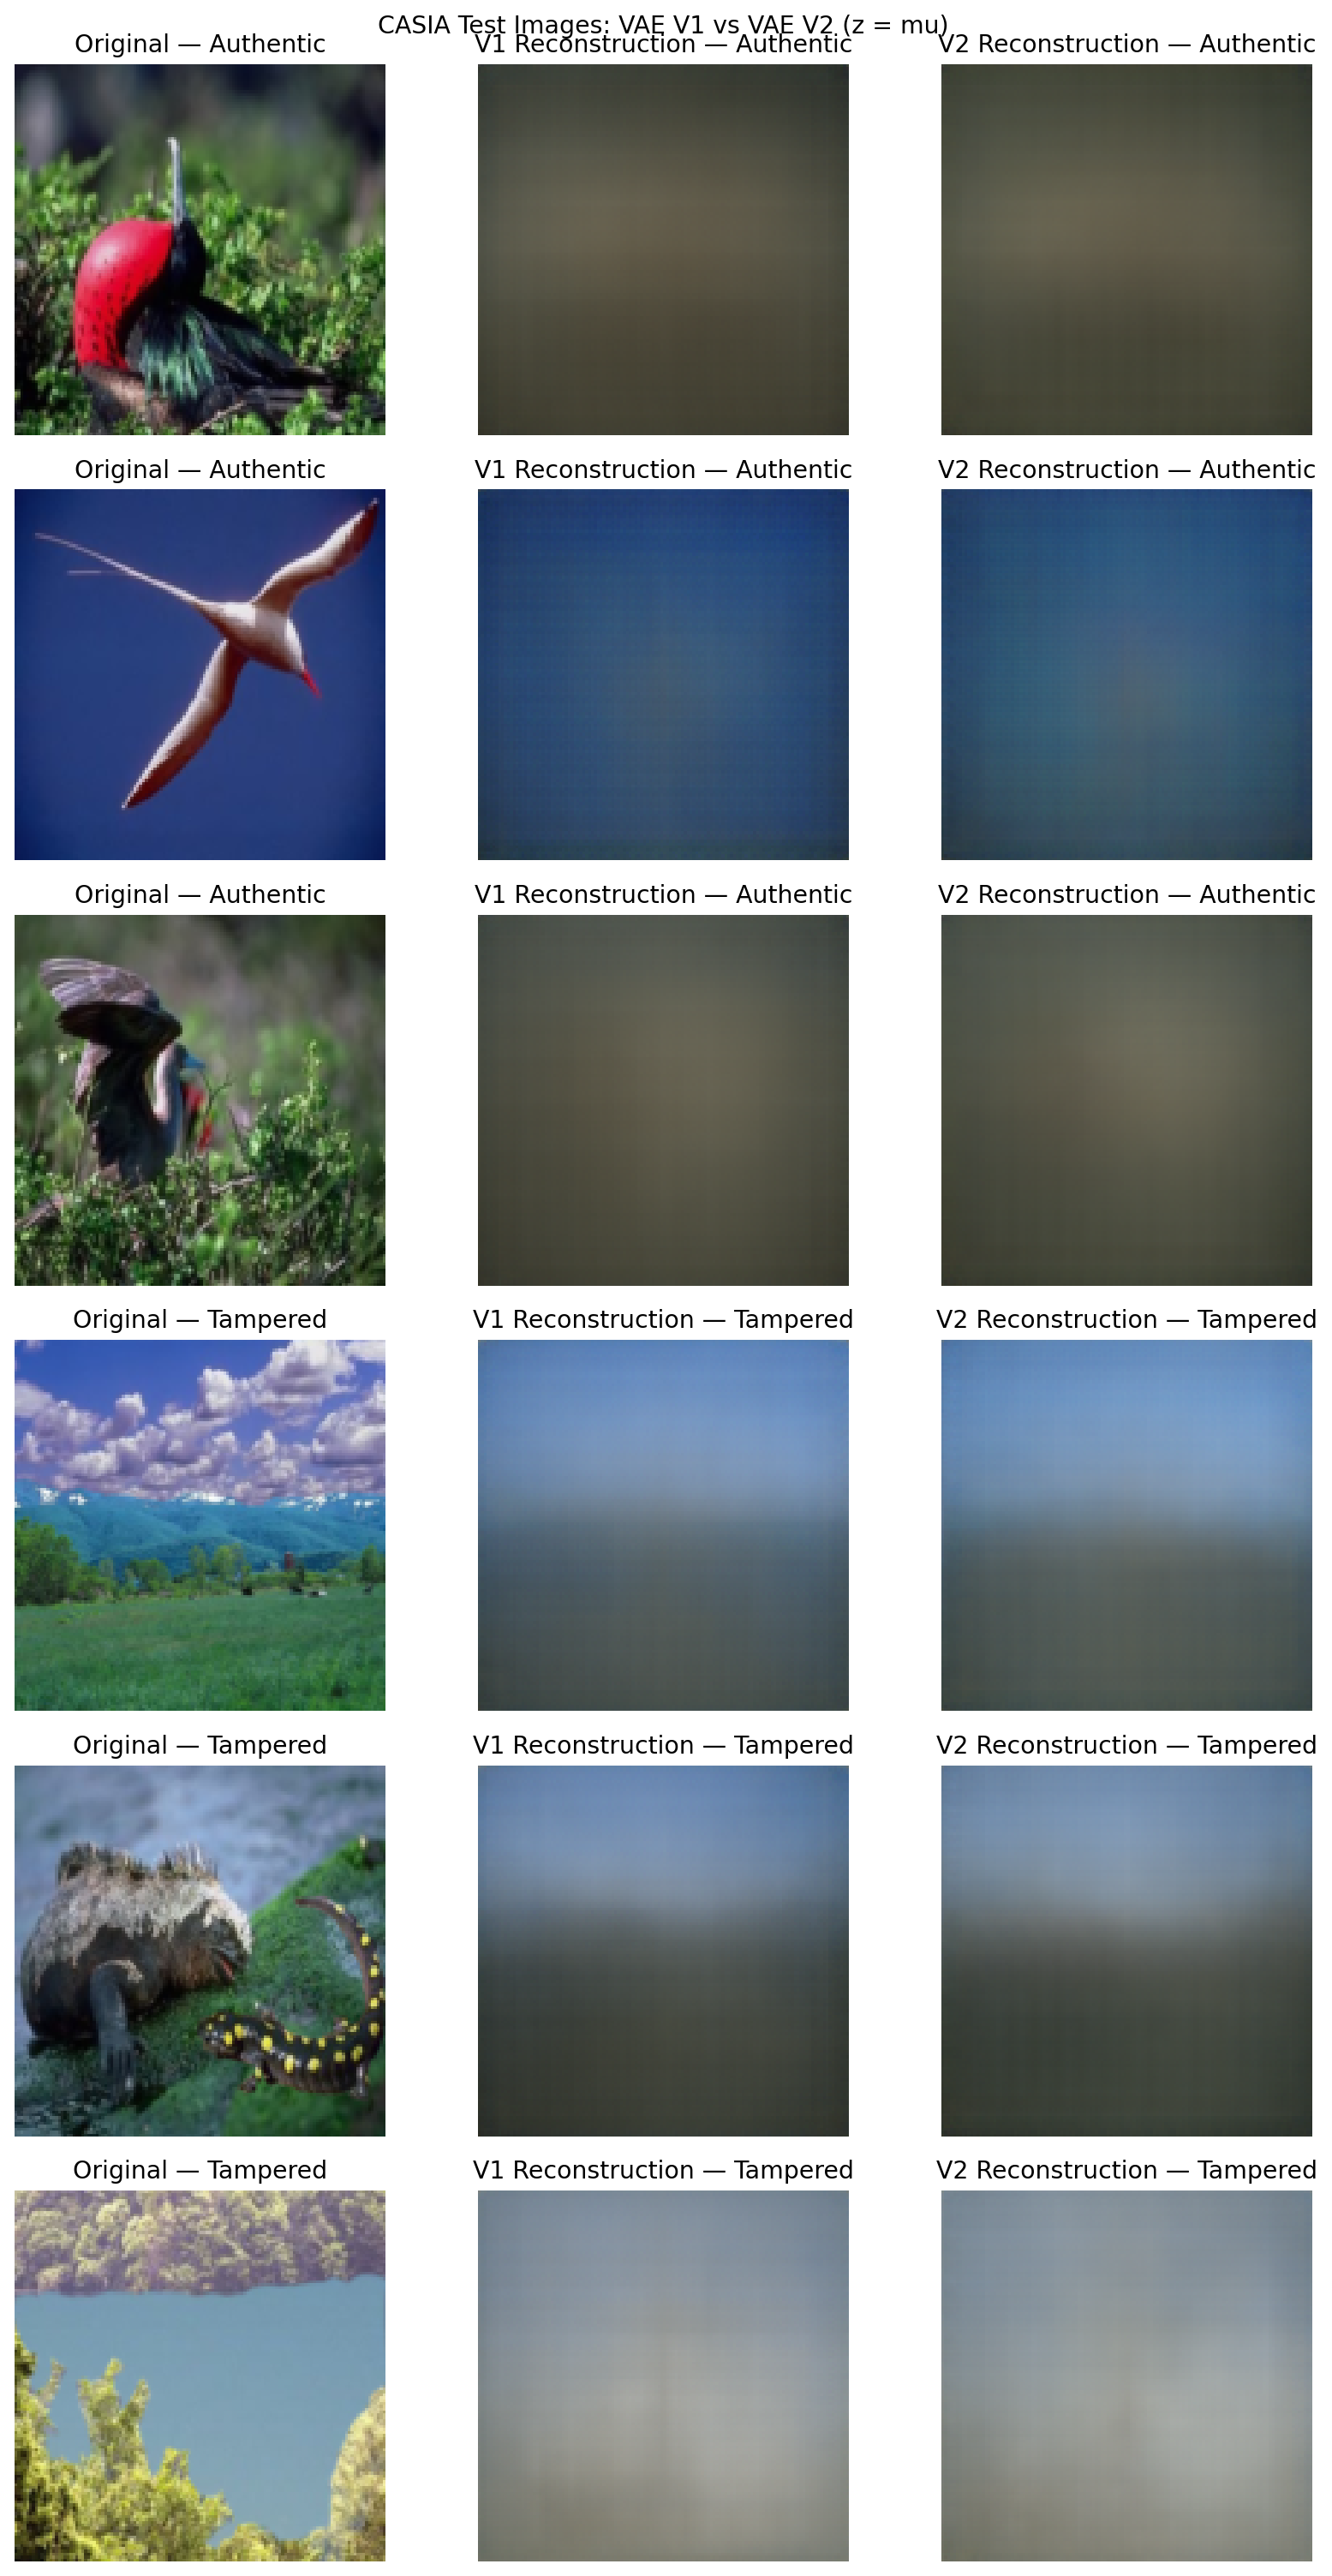

## V1 versus V2 final test results

| Metric | V1 baseline | V2 KL warm-up | Direction |
|---|---:|---:|---|
| MSE | 0.02909885 | **0.02816802** | 3.20% lower |
| PSNR | 15.7895 dB | **15.9348 dB** | 0.92% higher |
| SSIM | 0.287554 | **0.290189** | 0.92% higher |
| FID | 339.579 | **321.358** | 5.37% lower |
| KL | 7.139858 | 8.219714 | Probabilistic regularization retained |

V2 improved all three reconstruction metrics and FID. The improvement is modest, and reconstructions remain smooth because the architecture and pixel-wise MSE objective are unchanged.

In [8]:
# Load V2 without retraining and verify its saved checkpoint.
TRAIN_VAE_V2 = False
v2_checkpoint_path = PROJECT_ROOT/'checkpoints/best_vae_v2.pth'
v2_checkpoint = torch.load(v2_checkpoint_path, map_location=device, weights_only=False)
v2_model = ConvolutionalVAE(latent_dim=128).to(device)
v2_model.load_state_dict(v2_checkpoint['model_state_dict'])
v2_model.eval()
print('TRAIN_VAE_V2:', TRAIN_VAE_V2)
print('Loaded V2 checkpoint:', v2_checkpoint_path)
print('Best epoch:', v2_checkpoint['epoch'])

TRAIN_VAE_V2: False
Loaded V2 checkpoint: C:\Users\Chetanraje\Desktop\GAA\Digital_Evidence\checkpoints\best_vae_v2.pth
Best epoch: 43


In [9]:
# Verified final V2 summary
v2_metrics = json.loads((PROJECT_ROOT/'results/vae_v2_test_metrics.json').read_text())
v2_training = json.loads((PROJECT_ROOT/'results/vae_v2_training_summary.json').read_text())
v2o = v2_metrics['overall']
print('V1: MSE=0.02909885, PSNR=15.7895, SSIM=0.287554, FID=339.579')
print(f"V2: MSE={v2o['mse_mean']:.8f}, PSNR={v2o['psnr_mean']:.4f}, SSIM={v2o['ssim_mean']:.6f}, FID={v2_metrics['fid']:.3f}, KL={v2o['kl_loss_mean']:.6f}")
print('Best epoch:', v2_training['best_epoch'])
print('Training time:', v2_training['training_time_seconds'], 'seconds')
print('V2 improved reconstruction: True')
print('V2 improved generation: True')

V1: MSE=0.02909885, PSNR=15.7895, SSIM=0.287554, FID=339.579
V2: MSE=0.02816802, PSNR=15.9348, SSIM=0.290189, FID=321.358, KL=8.219714
Best epoch: 43
Training time: 1363.9269068180001 seconds
V2 improved reconstruction: True
V2 improved generation: True


## Updated conclusion

KL warm-up produced a measurable improvement over the baseline without changing the architecture or discarding probabilistic regularization. V2 is therefore the preferred VAE result for this project, while V1 remains the reproducible baseline. Generated outputs remain synthetic research images, and neither model should be presented as a forgery detector.